# Análisis de patrones espaciales

In [1]:
!pip -q install geopandas pandas shapely pyproj rioxarray rasterio mapclassify folium

import os, glob, numpy as np, pandas as pd, geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 56.3 MB/s eta 0:00:00


In [3]:

import geopandas as gpd
import numpy as np
from shapely.geometry import Point
import os, glob, matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from rasterio.transform import from_origin
import rasterio
import rioxarray as rxr
from mapclassify import NaturalBreaks
import folium
from folium import plugins

# 📂 Carpeta de trabajo local
os.chdir("/content")

# 🔹 Ver shapefiles disponibles
lista_shp = glob.glob("*.shp")
print("Archivos encontrados:", lista_shp)

# Carga tus capas (ajusta si los nombres difieren)
Perdida = gpd.read_file(lista_shp[0])
Limite  = gpd.read_file(lista_shp[1])

print("Campos:", Perdida.columns.tolist())
print("CRS:", Perdida.crs)


Archivos encontrados: ['perdida_2001_2024.shp', 'provincia.shp']
Campos: ['OBJECTID', 'Id', 'gridcode', 'Año', 'Area', 'geometry']
CRS: EPSG:32718


In [4]:
# Crear tabla resumen con conteo
tabla = Perdida.groupby("gridcode").size().reset_index(name="count")

# Copia con campo de conteo (sin alterar la original)
Perdida_count = Perdida.merge(tabla, on="gridcode", how="left")
Perdida_count.head()


,OBJECTID,Id,gridcode,Año,Area,geometry,count
0,2360029,2360029,3,2003,0.45,"POLYGON ((331558 9256318.991, 331558 9256290, ...",5669
1,2360376,2360376,11,2011,0.18,"POLYGON ((331498 9256260, 331528 9256260, 3315...",7162
2,2360794,2360794,24,2024,0.99,"MULTIPOLYGON (((331258 9256162.615, 331258 925...",6210
3,2360795,2360795,12,2012,0.27,"POLYGON ((331288 9256178.253, 331288 9256170, ...",7508
4,2360796,2360796,24,2024,0.45,"POLYGON ((331438 9256140, 331408 9256140, 3313...",6210


In [5]:
# Convertir a UTM (ajusta EPSG si trabajas fuera de Sudamérica Sur)
Perdida_UTM = Perdida_count.to_crs("EPSG:32718")
Limite_UTM  = Limite.to_crs("EPSG:32718")

# Calcular área (hectáreas)
Perdida_UTM["Area_ha"] = Perdida_UTM.geometry.area / 10000

# Crear campo de año (Anual = gridcode + 2000)
Perdida_UTM["Anual"] = Perdida_UTM["gridcode"] + 2000

# Calcular centroides
Centros = Perdida_UTM.copy()
Centros["geometry"] = Perdida_UTM.centroid
Centros.head(6)


,OBJECTID,Id,gridcode,Año,Area,geometry,count,Area_ha,Anual
0,2360029,2360029,3,2003,0.45,POINT (331515.03 9256282.442),5669,0.229814,2003
1,2360376,2360376,11,2011,0.18,POINT (331513 9256230),7162,0.180000,2011
2,2360794,2360794,24,2024,0.99,POINT (331279.778 9256166.273),6210,0.105984,2024
3,2360795,2360795,12,2012,0.27,POINT (331288.539 9256155.278),7508,0.181302,2012
4,2360796,2360796,24,2024,0.45,POINT (331399 9256173),6210,0.450000,2024
5,2360797,2360797,24,2024,0.18,POINT (331603 9256170),6210,0.180000,2024


In [15]:
Y = 2022  # 🔁 Cambia el año que quieras analizar

Centros_Y = Centros[Centros["Anual"] == Y].copy()
print(f"N° de polígonos en {Y}: {len(Centros_Y)}")

# Calcular centro medio y mediana espacial
coords = np.array(list(zip(Centros_Y.geometry.x, Centros_Y.geometry.y)))
centro_medio = Point(coords.mean(axis=0))
x_mediana, y_mediana = np.median(coords[:,0]), np.median(coords[:,1])
mediana_espacial = Point(x_mediana, y_mediana)

# Crear GeoDataFrame de centros
gdf_centros = gpd.GeoDataFrame(
    {"tipo":["centro_medio","mediana"],
     "geometry":[centro_medio, mediana_espacial]},
    crs=Centros_Y.crs
)

# Crear buffer de 2 km y disolver
zona_buffer = Centros_Y.copy()
zona_buffer["geometry"] = Centros_Y.buffer(2000)
zona_buffer1 = zona_buffer.dissolve()

# Exportar resultados
outdir = f"/content/Resultados_{Y}"
os.makedirs(outdir, exist_ok=True)
Centros_Y.to_file(f"{outdir}/Centros_{Y}.shp")
gdf_centros.to_file(f"{outdir}/centros_mediana_media.shp")
zona_buffer1.to_file(f"{outdir}/buffer_disuelto.shp")
print("✔️ Exportados a:", outdir)


N° de polígonos en 2022: 8390
✔️ Exportados a: /content/Resultados_2022


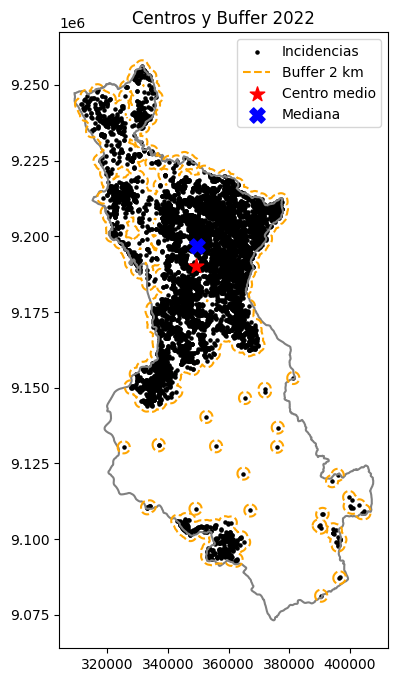

In [16]:
fig, ax = plt.subplots(figsize=(8,8))
Limite_UTM.boundary.plot(ax=ax, color='gray')
Centros_Y.plot(ax=ax, color='black', markersize=5, label='Incidencias')
zona_buffer1.boundary.plot(ax=ax, color='orange', linestyle='--', label='Buffer 2 km')
gdf_centros[gdf_centros['tipo']=="centro_medio"].plot(ax=ax, color='red', marker='*', markersize=120, label='Centro medio')
gdf_centros[gdf_centros['tipo']=="mediana"].plot(ax=ax, color='blue', marker='X', markersize=120, label='Mediana')
ax.legend()
ax.set_title(f"Centros y Buffer {Y}")
plt.show()


In [17]:
search_radius = 1000  # m
cell_size = 30        # m

minx, miny, maxx, maxy = Centros_Y.total_bounds
minx -= search_radius; miny -= search_radius
maxx += search_radius; maxy += search_radius
width  = int((maxx-minx)/cell_size)
height = int((maxy-miny)/cell_size)

# Construir grilla de densidad
grid = np.zeros((height,width),dtype=float)
def coord_to_index(x,y):
    col=int((x-minx)/cell_size)
    row=int((maxy-y)/cell_size)
    return row,col

for _,r in Centros_Y.iterrows():
    row,col=coord_to_index(r.geometry.x,r.geometry.y)
    if 0<=row<height and 0<=col<width:
        grid[row,col]+=r["Area_ha"]

sigma = search_radius/cell_size
smoothed = gaussian_filter(grid, sigma=sigma)
transform = from_origin(minx, maxy, cell_size, cell_size)

# Guardar raster KDE
kde_path = f"{outdir}/Densidad_KDE_{Y}.tif"
with rasterio.open(kde_path,'w',driver='GTiff',height=smoothed.shape[0],
                   width=smoothed.shape[1],count=1,dtype=smoothed.dtype,
                   crs=Centros_Y.crs,transform=transform) as dst:
    dst.write(smoothed,1)

# Recorte por buffer disuelto
da = rxr.open_rasterio(kde_path, masked=True)
kde_clip = da.rio.clip(zona_buffer1.geometry)
clip_path = f"{outdir}/KDE_{Y}_clip.tif"
kde_clip.rio.to_raster(clip_path)
print("✔️ Raster KDE recortado:", clip_path)


✔️ Raster KDE recortado: /content/Resultados_2022/KDE_2022_clip.tif


In [18]:
CentrosY_geo = Centros_Y.to_crs(4326)
Limite_geo = Limite_UTM.to_crs(4326)
center = [CentrosY_geo.geometry.y.mean(), CentrosY_geo.geometry.x.mean()]

m = folium.Map(location=center, zoom_start=10, tiles='Esri.WorldImagery')
plugins.HeatMap([[p.y, p.x] for p in CentrosY_geo.geometry]).add_to(m)
folium.GeoJson(Limite_geo, name="Límite",
               style_function=lambda f: {"fillColor":"none","color":"black","weight":2}).add_to(m)
folium.LayerControl().add_to(m)

map_path = f"{outdir}/Mapa_Heat_{Y}.html"
m.save(map_path)
m


In [19]:
# ================================
# Clasificación en 6 clases (Jenks) sin NoData
# ================================
import os
import numpy as np
import rasterio
from rasterio.transform import Affine
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from rasterio.plot import show
from mapclassify import NaturalBreaks

# ---- Entradas
Y = 2021 # 🔁 Cambiar de 2020 a 2021 para que coincida con el año generado anteriormente
outdir = f"/content/Resultados_{Y}"
in_path  = f"{outdir}/KDE_{Y}_clip.tif" # raster CONTINUO ya recortado (cambiar KDE_{Y}.tif a KDE_{Y}_clip.tif)
out_path = f"{outdir}/KDE_{Y}_clas6.tif" # salida clasificada (1..6, 0=fondo)

# ---- Leer raster
with rasterio.open(in_path) as src:
    arr = src.read(1)
    profile = src.profile
    transform = src.transform
    crs = src.crs

# ---- Máscara de valores válidos (usamos >0 para KDE)
mask = arr > 0
vals = arr[mask]
if vals.size == 0:
    raise RuntimeError("No hay valores > 0 para clasificar. Revisa el raster de entrada.")

# ---- Clasificación Jenks (6 clases)
k = 5
nb = NaturalBreaks(vals, k=k)
classes = np.zeros_like(arr, dtype=np.uint8)  # 0 = fondo
classes[mask] = nb.find_bin(arr[mask]) + 1    # 1..6

# ---- Guardar sin NoData (fondo=0)
profile.update(dtype=rasterio.uint8, count=1, nodata=None)  # sin nodata
with rasterio.open(out_path, "w", **profile) as dst:
    dst.write(classes, 1)

print("✅ Raster clasificado guardado:", out_path)
print("Umbrales Jenks (6 clases):", np.round(nb.bins, 6).tolist())

✅ Raster clasificado guardado: /content/Resultados_2021/KDE_2021_clas6.tif
Umbrales Jenks (6 clases): [0.000313, 0.000787, 0.001394, 0.002304, 0.004259]


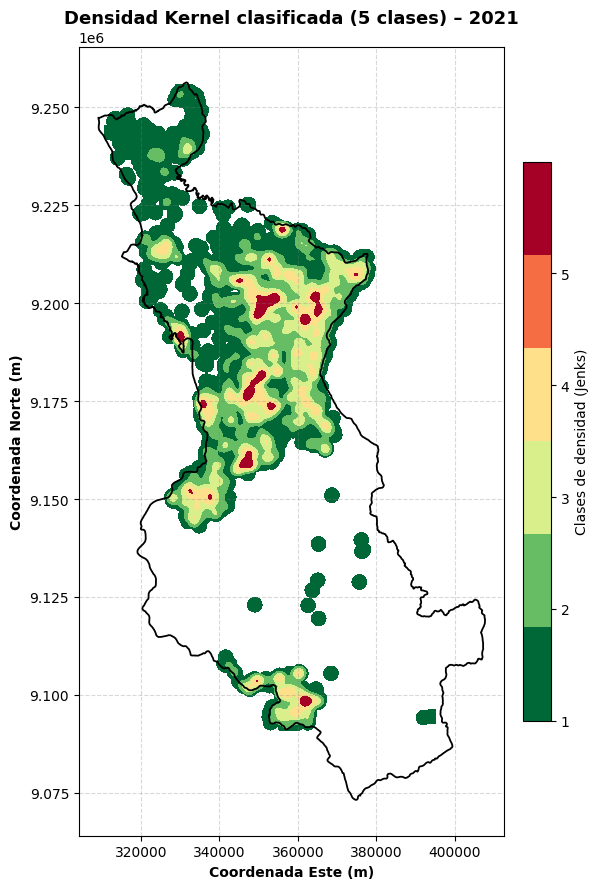

In [21]:
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from matplotlib.colors import BoundaryNorm, Normalize

# --- Entradas
Y = 2021 # Se corrigió el año a 2021 para que coincida con el año generado anteriormente
outdir = f"/content/Resultados_{Y}"
raster_path = f"{outdir}/KDE_{Y}_clas6.tif"
limite_path = "/content/provincia.shp" # Se corrigió el nombre del shapefile

# --- Leer datos
src = rasterio.open(raster_path)
arr = src.read(1)
crs_r = src.crs
extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

limite = gpd.read_file(limite_path).to_crs(crs_r)

# --- Reemplazar valores nulos por np.nan
arr = np.where(arr == 0, np.nan, arr)

# --- Paleta RdYlGn (invertida)
cmap = plt.colormaps.get("RdYlGn_r").resampled(6)
norm = BoundaryNorm(np.arange(1, 7), cmap.N)

# --- Figura
fig, ax = plt.subplots(figsize=(10, 9), facecolor="white")

# Mostrar raster (sin fondo, los nan quedan blancos)
im = ax.imshow(arr, cmap=cmap, norm=norm, extent=extent,
               origin="upper", interpolation="nearest")

# Límite negro encima
limite.boundary.plot(ax=ax, color="black", linewidth=1.3)

# Estilo general
ax.set_aspect("equal")
ax.set_title(f"Densidad Kernel clasificada (5 clases) – {Y}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Coordenada Este (m)", fontweight="bold")
ax.set_ylabel("Coordenada Norte (m)", fontweight="bold")
ax.grid(True, linestyle="--", color="gray", alpha=0.3)

# Barra de color
cbar = plt.colorbar(
    plt.cm.ScalarMappable(norm=Normalize(vmin=1, vmax=6), cmap=cmap),
    ax=ax, fraction=0.03, pad=0.02
)
cbar.set_ticks([1, 2, 3, 4, 5])
cbar.set_label("Clases de densidad (Jenks)", fontsize=10)

plt.tight_layout()
plt.show()